# SPY Risk Management Under Instability: A 60/40 Tactical Sleeve

**Goal.** Build a no-lookahead automatic risk-management stack that keeps **60% in SPY at all times** and uses a **40% tactical sleeve** only during extreme risk-off windows. The tactical sleeve is evaluated through three lenses: a Markov transition model, a Bayesian posterior model, and a walk-forward ML model.

**Why this notebook exists**
1. SPY has a strong positive drift, so naive de-risking often destroys long-run return.
2. Panic is not the same thing as a short signal. In the previous SPY/VIX study, severe stress often behaved more like a future rebound setup than a continuation setup.
3. A Medallion-style mindset means *small edges, strict leakage controls, and regime-specific capital allocation*, not one heroic forecast.

**Research questions**
1. Can we detect extreme risk-off regimes from current and trailing market plus macro context without lookahead?
2. Inside those regimes, is the next move more likely to be continuation or rebound?
3. Does a 60% core plus 40% tactical sleeve beat simpler heuristics on instability-adjusted performance?
4. Which modelling family looks most sound: Markov transitions, Bayesian shrinkage, or walk-forward ML?


## 1. Load the research outputs

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.4f}'.format

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESEARCH_DIR = PROJECT_ROOT / 'outputs' / 'spy_regime_risk_management'
print('research dir:', RESEARCH_DIR)

research dir: D:\dev\price_action\outputs\spy_regime_risk_management


In [2]:
with open(RESEARCH_DIR / 'spy_regime_risk_management_summary.json', encoding='utf-8') as f:
    summary = json.load(f)

drift = pd.read_csv(RESEARCH_DIR / 'drift_summary.csv')
events = pd.read_csv(RESEARCH_DIR / 'extreme_risk_off_events.csv', parse_dates=['signal_date', 'entry_date'])
state_summary = pd.read_csv(RESEARCH_DIR / 'event_state_summary.csv')
transition_summary = pd.read_csv(RESEARCH_DIR / 'markov_transition_summary.csv')
model_metrics = pd.read_csv(RESEARCH_DIR / 'model_metrics.csv')
event_predictions = pd.read_csv(RESEARCH_DIR / 'event_model_predictions.csv', parse_dates=['signal_date'])
strategy_summary = pd.read_csv(RESEARCH_DIR / 'strategy_summary.csv')
strategy_periods = pd.read_csv(RESEARCH_DIR / 'strategy_periods.csv', parse_dates=['signal_date'])
panel = pd.read_csv(RESEARCH_DIR / 'risk_management_signal_panel.csv', parse_dates=['signal_date', 'entry_date'])

headline = pd.DataFrame({
    'metric': ['panel rows', 'extreme risk-off events', 'predicted events', 'hold days', 'core weight', 'tactical sleeve'],
    'value': [summary['rows'], summary['extreme_risk_off_events'], summary['prediction_rows'], summary['hold_days'], summary['core_weight'], summary['tactical_weight']],
})
display(headline)

,metric,value
0,panel rows,"6,607.0000"
1,extreme risk-off events,"1,205.0000"
2,predicted events,"1,205.0000"
3,hold days,5.0000
4,core weight,0.6000
5,tactical sleeve,0.4000


## 2. Leakage controls first

If the leakage controls are not sound, nothing else matters. The research module uses four rules:
1. Features come only from current and trailing history.
2. The sleeve enters **one bar after** the signal date.
3. Markov and Bayesian probabilities are expanding-history estimates.
4. ML predictions are walk-forward and only evaluated out of sample.


In [3]:
for guardrail in summary['leakage_guardrails']:
    print('-', guardrail)

- All regime features are computed from current and trailing history only.
- The tactical sleeve enters on the next bar after the signal date.
- Markov and Bayesian estimates use expanding history only; ML predictions are walk-forward and never see future labels in training.
- Strategy periods are sampled on a non-overlapping hold-day schedule.


## 3. The positive-drift problem

SPY rises more often than it falls over medium horizons. That means a tactical sleeve should not react to fear alone. It has to beat the positive drift that already exists in the baseline.

,group,observations,mean_return,median_return,positive_rate,signal_to_noise,t_stat
0,all_dates,6601,0.0019,0.0036,0.5816,0.0770,6.2527
1,risk_off_dates,1676,0.0032,0.0064,0.5847,0.0884,3.6184
2,extreme_risk_off_dates,1205,0.0031,0.0063,0.5759,0.0788,2.7354
3,non_risk_off_dates,4925,0.0015,0.0031,0.5805,0.0758,5.3188


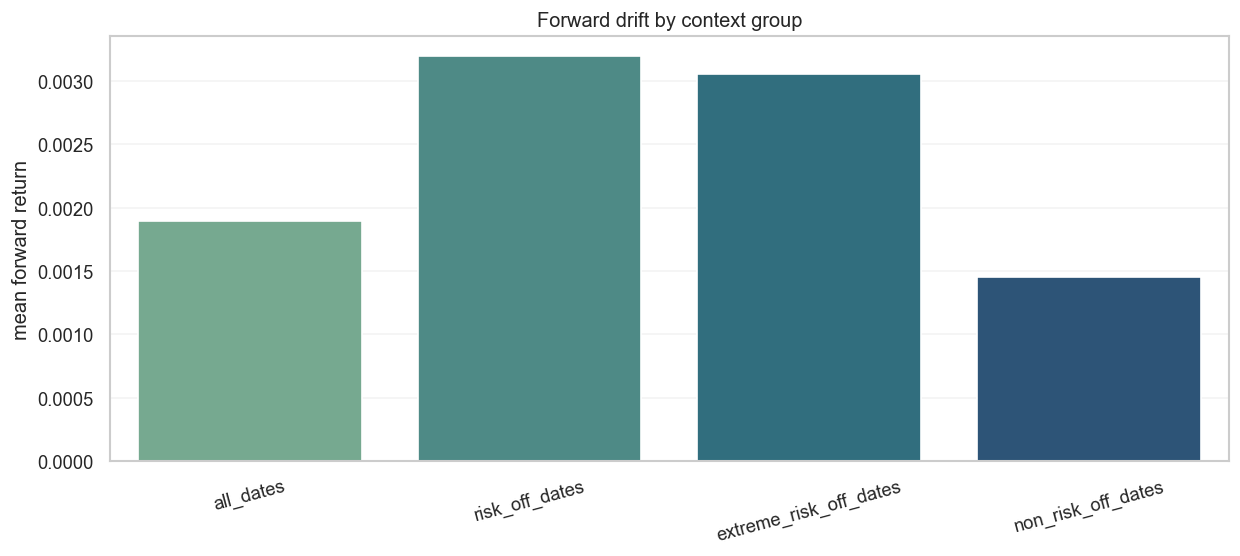

In [4]:
display(drift)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.barplot(data=drift, x='group', y='mean_return', hue='group', dodge=False, legend=False, palette='crest', ax=ax)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Forward drift by context group')
ax.set_xlabel('')
ax.set_ylabel('mean forward return')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Defining the extreme risk-off window

The sleeve only activates when market stress and macro fragility line up. The gate is deliberately strict because false positives are expensive against a market with positive drift.

,source_state,events,mean_event_return,median_event_return,positive_rate,avg_panic_score,avg_macro_fragility_score,benign_transition_rate,adverse_transition_rate,signal_to_noise
0,Fear|macro_high,362,0.0013,0.0036,0.5414,1.4144,1.4521,0.1989,0.8011,0.3506
1,Fear|macro_low,231,0.0035,0.0072,0.6190,1.4123,-0.4567,0.3680,0.6320,0.4862
2,Panic|macro_high,165,0.0050,0.0134,0.6061,2.7639,1.6482,0.0061,0.9939,0.3724
3,Fear|macro_mid,127,-0.0001,0.0038,0.5276,1.3735,0.5149,0.2362,0.7638,-0.0147
4,Unclassified|macro_high,106,0.0084,0.0106,0.6415,1.2889,1.1318,0.0000,0.0000,0.7914
5,Unclassified|macro_low,95,-0.0065,-0.0032,0.4421,1.4422,-0.3728,0.0000,0.0000,-2.0124
6,Unclassified|macro_mid,70,0.0123,0.0119,0.6429,1.4967,0.4933,0.0000,0.0429,1.0370
7,Panic|macro_mid,22,0.0133,0.0274,0.7727,1.9779,0.4901,0.0909,0.9091,0.4857
8,Panic|macro_low,15,0.0135,0.0228,0.7333,3.1231,0.0113,0.0667,0.9333,0.5907
9,Neutral|macro_low,8,0.0017,0.0014,0.5000,0.8845,-0.4946,0.6250,0.3750,1.2519


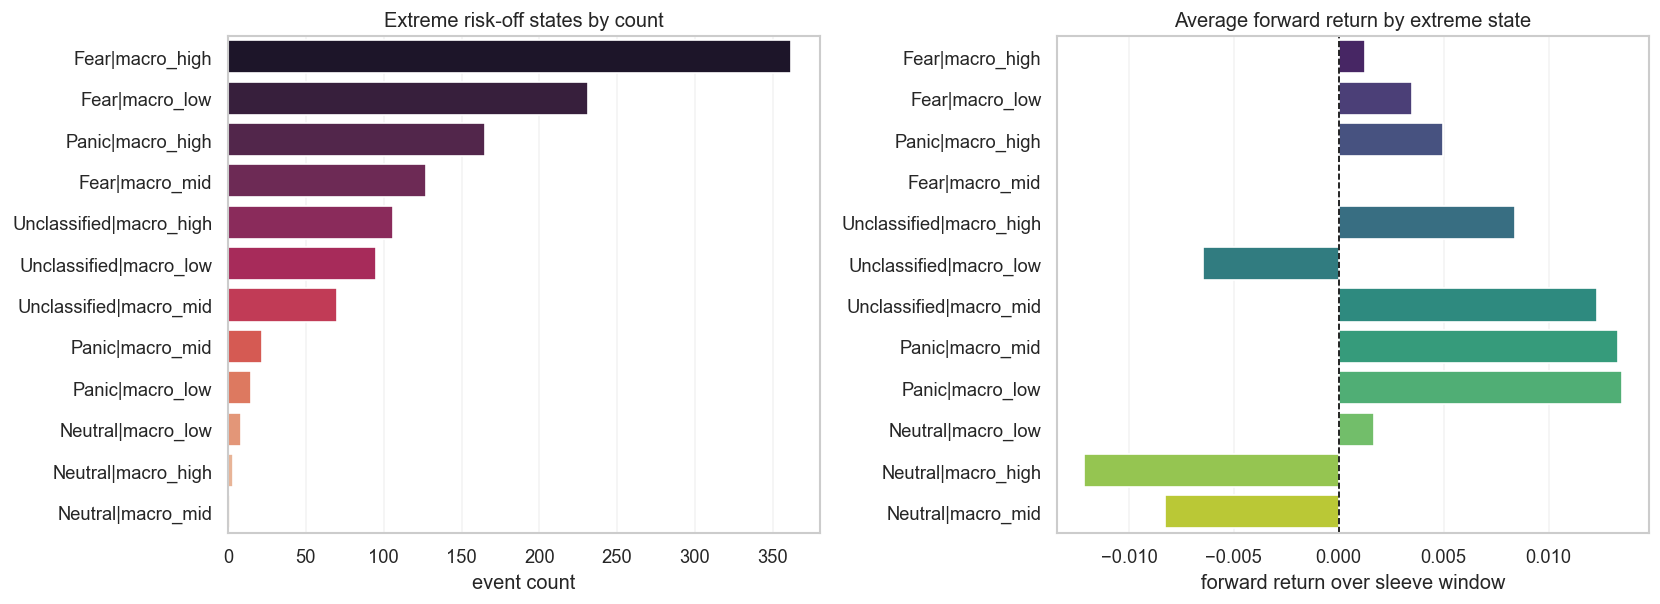

In [5]:
display(state_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.barplot(data=state_summary, y='source_state', x='events', hue='source_state', dodge=False, legend=False, palette='rocket', ax=axes[0])
axes[0].set_title('Extreme risk-off states by count')
axes[0].set_xlabel('event count')
axes[0].set_ylabel('')

sns.barplot(data=state_summary, y='source_state', x='mean_event_return', hue='source_state', dodge=False, legend=False, palette='viridis', ax=axes[1])
axes[1].axvline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_title('Average forward return by extreme state')
axes[1].set_xlabel('forward return over sleeve window')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Markov chain view

The Markov lens asks: *when the market enters this extreme state, where does it tend to go next by the sleeve exit?* This is transition modelling, not prediction magic. The edge comes from asymmetry in the transition table.

,source_state,future_sentiment_state,transition_count,mean_event_return,positive_rate,avg_panic_score,avg_macro_fragility_score
0,Fear|macro_high,Fear,238,0.0016,0.5126,1.4932,1.4915
1,Fear|macro_high,Neutral,70,0.0283,0.9143,1.0660,1.4341
2,Fear|macro_high,Panic,52,-0.0380,0.1538,1.5392,1.2892
3,Fear|macro_high,Greed,2,0.0380,1.0000,0.9722,1.6421
4,Fear|macro_low,Fear,128,-0.0036,0.4844,1.5493,-0.4297
5,Fear|macro_low,Neutral,71,0.0208,0.9014,1.1982,-0.5660
6,Fear|macro_low,Panic,18,-0.0321,0.1667,1.5526,-0.2676
7,Fear|macro_low,Greed,14,0.0259,1.0000,1.0642,-0.3918
8,Fear|macro_mid,Fear,82,-0.0006,0.5000,1.4570,0.5239
9,Fear|macro_mid,Neutral,28,0.0229,0.8214,1.0545,0.4742


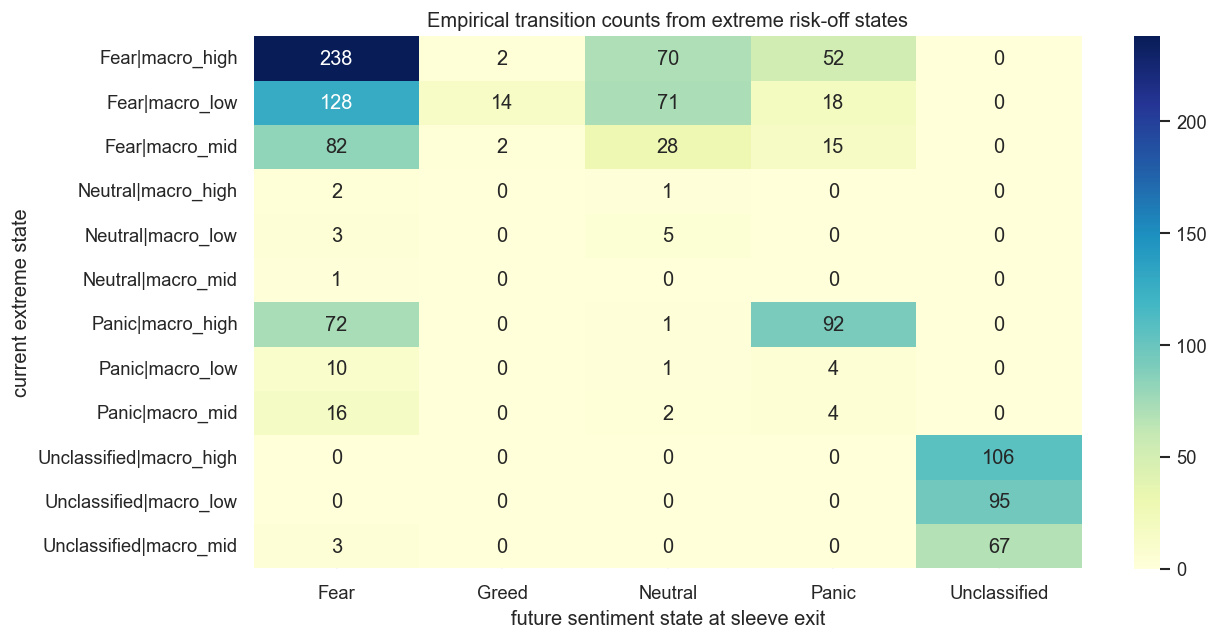

In [6]:
display(transition_summary.round(4))

heatmap = transition_summary.pivot(index='source_state', columns='future_sentiment_state', values='transition_count').fillna(0)
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(heatmap, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title('Empirical transition counts from extreme risk-off states')
ax.set_xlabel('future sentiment state at sleeve exit')
ax.set_ylabel('current extreme state')
plt.tight_layout()
plt.show()

## 6. Bayesian shrinkage view

The Bayesian model takes the same state-level evidence but shrinks it toward the global instability baseline. This is the right mindset when event counts are small: do not trust a sparse state as much as a broad prior.

In [7]:
posterior_cols = [
    'signal_date', 'bayesian_expected_return', 'bayesian_positive_prob', 'bayesian_training_mean_return', 'bayesian_training_positive_rate'
]
display(event_predictions[posterior_cols].dropna().head(12).round(4))

,signal_date,bayesian_expected_return,bayesian_positive_prob,bayesian_training_mean_return,bayesian_training_positive_rate
180,2004-05-19,-0.0069,0.3945,0.0031,0.5111
181,2004-05-20,-0.0065,0.4013,0.0033,0.5138
182,2004-05-21,-0.0061,0.4080,0.0034,0.5165
183,2004-07-21,0.0146,0.6221,0.0035,0.5191
184,2004-07-23,-0.0058,0.4152,0.0035,0.5217
185,2004-07-26,-0.0055,0.4216,0.0036,0.5243
186,2004-07-27,-0.0054,0.4279,0.0036,0.5269
187,2004-08-05,0.0145,0.6329,0.0036,0.5294
188,2004-08-06,0.0143,0.6401,0.0036,0.5319
189,2004-08-09,0.0143,0.6471,0.0037,0.5344


## 7. Walk-forward ML view

The ML block is intentionally modest. It predicts the tactical sleeve return from lagged SPY, VIX, credit, financial conditions, curve stress, policy uncertainty, and release-aware consumer sentiment.

,scope,model_name,observations,roc_auc,brier_score,prediction_return_corr,mean_predicted_return,mean_actual_return,top_quintile_mean_return,bottom_quintile_mean_return,top_quintile_signal_to_noise,bottom_quintile_signal_to_noise,positive_rate,sign_accuracy
0,all,bayesian,1025,0.5168,0.2448,0.0128,0.0016,0.0030,0.0039,0.0018,0.1582,0.0310,0.5873,0.5590
1,all,ensemble,1025,0.5130,0.2467,-0.0566,0.0023,0.0030,0.0003,0.0065,0.0096,0.1262,0.5873,0.5346
2,all,markov,1025,0.5114,0.2459,-0.0254,0.0015,0.0030,0.0032,0.0043,0.1186,0.0720,0.5873,0.5493
3,all,ml,804,0.4971,0.2717,-0.0443,0.0039,0.0028,0.0036,0.0044,0.0605,0.1089,0.5808,0.4925
4,holdout,ensemble,297,0.5203,0.2475,-0.0324,0.0012,0.0033,0.0034,0.0041,0.1078,0.0625,0.5758,0.5185
5,holdout,bayesian,297,0.5091,0.2442,-0.0018,0.0021,0.0033,0.0020,0.0042,0.0696,0.0652,0.5758,0.5724
6,holdout,ml,297,0.5088,0.2676,0.0372,0.0002,0.0033,0.0102,0.0069,0.1973,0.1479,0.5758,0.5152
7,holdout,markov,297,0.5009,0.2459,-0.0722,0.0014,0.0033,0.0021,0.0095,0.0689,0.1446,0.5758,0.4949
8,validation,bayesian,728,0.5187,0.2451,0.0170,0.0014,0.0029,0.0052,0.0009,0.2493,0.0160,0.5920,0.5536
9,validation,markov,728,0.5156,0.2459,-0.0001,0.0015,0.0029,0.0019,0.0027,0.0746,0.0494,0.5920,0.5714


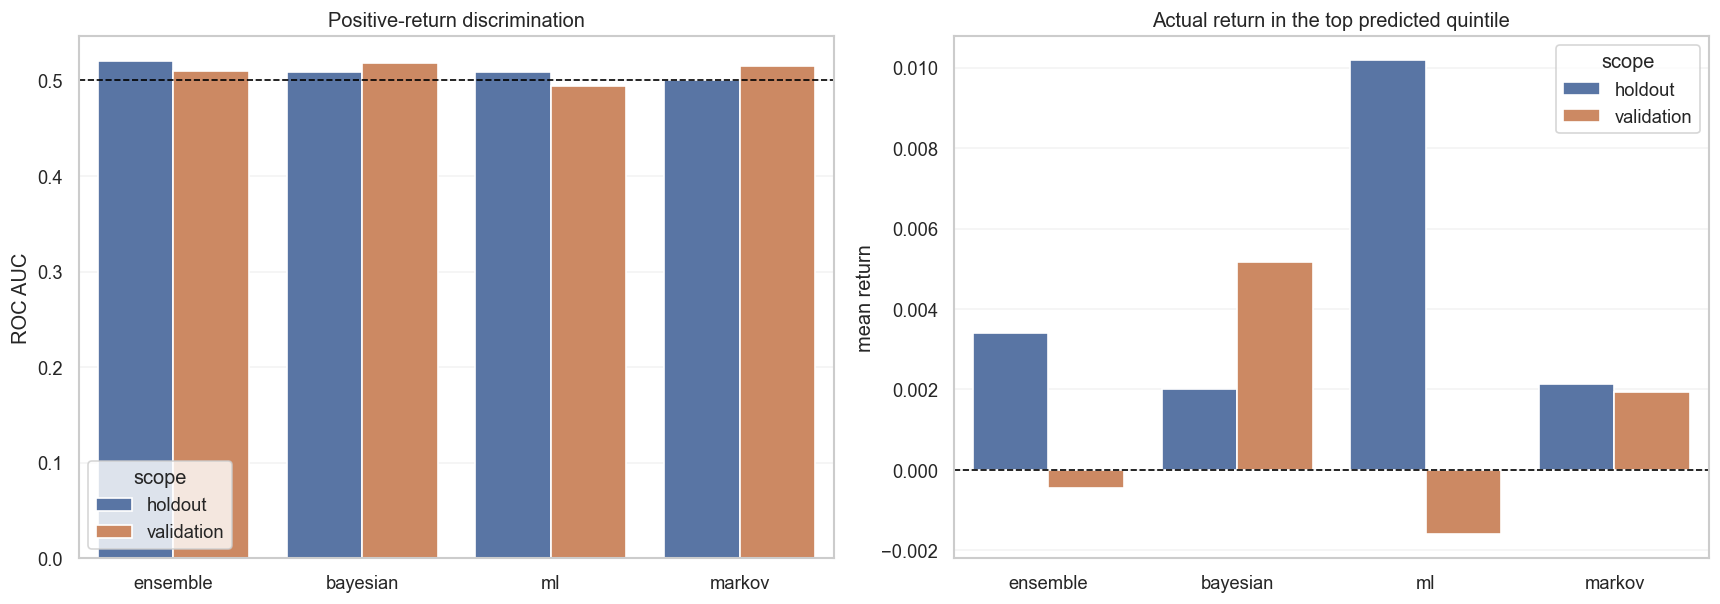

In [8]:
display(model_metrics.round(4))

metric_plot = model_metrics.loc[model_metrics['scope'].isin(['validation', 'holdout'])].copy()
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
sns.barplot(data=metric_plot, x='model_name', y='roc_auc', hue='scope', ax=axes[0])
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Positive-return discrimination')
axes[0].set_xlabel('')
axes[0].set_ylabel('ROC AUC')

sns.barplot(data=metric_plot, x='model_name', y='top_quintile_mean_return', hue='scope', ax=axes[1])
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_title('Actual return in the top predicted quintile')
axes[1].set_xlabel('')
axes[1].set_ylabel('mean return')
plt.tight_layout()
plt.show()

## 8. Ensemble and tactical capital allocation

The final sleeve averages the Markov, Bayesian, and ML expected returns and probabilities. The sleeve only deploys if the ensemble beats the historical instability baseline. That is the core drift-aware risk-management rule.

In [9]:
display(strategy_summary.round(4))

,strategy_name,hold_days,periods,active_periods,total_return,avg_return,avg_excess_return_vs_spy,avg_excess_return_vs_core,annualized_return,annualized_vol,signal_to_noise,hit_rate_vs_spy,hit_rate_vs_core,max_drawdown
0,bayesian_mobilized,5,1321,88,3.2465,0.0012,-0.0007,0.0001,0.0567,0.1162,0.0752,0.3823,0.0447,-0.3750
1,core_60_only,5,1321,0,2.9459,0.0012,-0.0008,0.0000,0.0538,0.1086,0.0756,0.4042,0.0000,-0.3639
2,ensemble_long_short,5,1321,77,3.1098,0.0012,-0.0007,0.0001,0.0554,0.1176,0.0730,0.3823,0.0363,-0.4331
3,ensemble_mobilized,5,1321,77,3.1098,0.0012,-0.0007,0.0001,0.0554,0.1176,0.0730,0.3823,0.0363,-0.4331
4,full_spy_100,5,1321,1321,7.2627,0.0019,0.0000,0.0008,0.0839,0.1810,0.0756,0.0000,0.5942,-0.5469
5,heuristic_panic_rebound,5,1321,198,4.1558,0.0015,-0.0005,0.0003,0.0646,0.1453,0.0711,0.3452,0.0908,-0.4449
6,markov_mobilized,5,1321,73,3.0563,0.0012,-0.0007,0.0000,0.0549,0.1147,0.0738,0.3830,0.0341,-0.3699
7,ml_mobilized,5,1321,62,2.5397,0.0011,-0.0008,-0.0000,0.0494,0.1251,0.0634,0.3853,0.0280,-0.4650


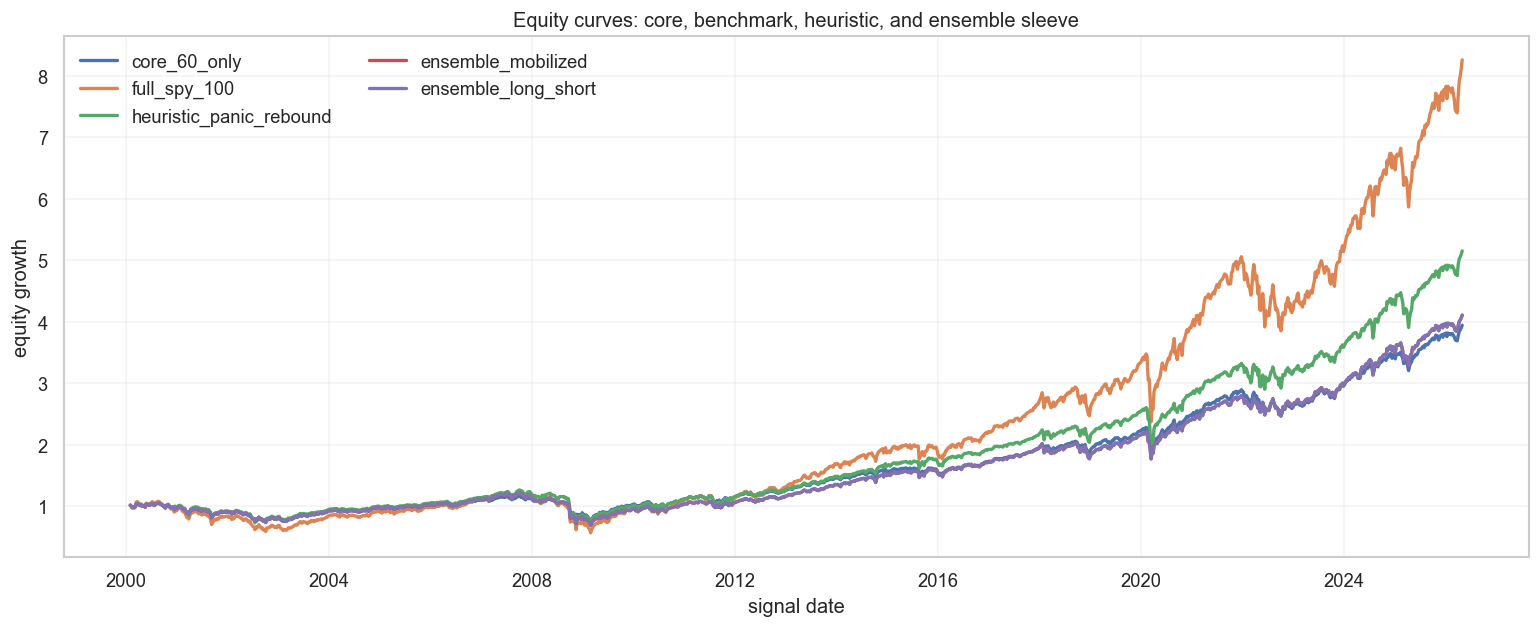

In [10]:
fig, ax = plt.subplots(figsize=(13, 5.4))
for strategy_name in ['core_60_only', 'full_spy_100', 'heuristic_panic_rebound', 'ensemble_mobilized', 'ensemble_long_short']:
    subset = strategy_periods.loc[strategy_periods['strategy_name'] == strategy_name].copy()
    if subset.empty:
        continue
    subset = subset.sort_values('signal_date')
    subset['equity'] = (1.0 + subset['strategy_return']).cumprod()
    ax.plot(subset['signal_date'], subset['equity'], linewidth=2.0, label=strategy_name)
ax.set_title('Equity curves: core, benchmark, heuristic, and ensemble sleeve')
ax.set_xlabel('signal date')
ax.set_ylabel('equity growth')
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

## 9. Where the model still fails

A sound model is not one that always makes money. It is one that shows you **where it fails** and why. If the tactical sleeve cannot reliably beat the drift baseline, the honest conclusion is that the sleeve is a risk-shaping tool, not a magic return engine.

In [11]:
display(
    strategy_periods.loc[strategy_periods['strategy_name'].isin(['heuristic_panic_rebound', 'ensemble_mobilized', 'ensemble_long_short'])]
    .groupby('strategy_name')[['strategy_return', 'spy_return', 'excess_return_vs_spy', 'excess_return_vs_core']]
    .mean()
    .round(4)
)

recent_bad = strategy_periods.loc[
    (strategy_periods['strategy_name'] == 'ensemble_long_short')
    & (strategy_periods['excess_return_vs_spy'] < 0.0)
].sort_values('signal_date', ascending=False).head(12)
display(recent_bad.round(4))

,strategy_return,spy_return,excess_return_vs_spy,excess_return_vs_core
strategy_name,,,,
ensemble_long_short,0.0012,0.0019,-0.0007,0.0001
ensemble_mobilized,0.0012,0.0019,-0.0007,0.0001
heuristic_panic_rebound,0.0015,0.0019,-0.0005,0.0003


,strategy_name,signal_date,entry_date,exit_date,hold_days,extreme_risk_off,sentiment_state,sleeve_weight,gross_exposure,strategy_return,spy_return,core_return,excess_return_vs_spy,excess_return_vs_core
3962,ensemble_long_short,2026-04-29,2026-04-30,2026-05-07,5,False,Neutral,0.0000,0.6000,0.0108,0.0180,0.0108,-0.0072,0.0000
3961,ensemble_long_short,2026-04-22,2026-04-23,2026-04-30,5,False,Neutral,0.0000,0.6000,0.0086,0.0144,0.0086,-0.0058,0.0000
3960,ensemble_long_short,2026-04-15,2026-04-16,2026-04-23,5,False,Neutral,0.0000,0.6000,0.0058,0.0097,0.0058,-0.0039,0.0000
3959,ensemble_long_short,2026-04-08,2026-04-09,2026-04-16,5,False,Fear,0.0000,0.6000,0.0192,0.0320,0.0192,-0.0128,0.0000
3958,ensemble_long_short,2026-03-31,2026-04-01,2026-04-09,5,True,Fear,0.0000,0.6000,0.0226,0.0377,0.0226,-0.0151,0.0000
3952,ensemble_long_short,2026-02-17,2026-02-18,2026-02-25,5,False,Neutral,0.0000,0.6000,0.0060,0.0100,0.0060,-0.0040,0.0000
3950,ensemble_long_short,2026-02-02,2026-02-03,2026-02-10,5,False,Neutral,0.0000,0.6000,0.0023,0.0038,0.0023,-0.0015,0.0000
3948,ensemble_long_short,2026-01-16,2026-01-20,2026-01-27,5,False,Greed,0.0000,0.6000,0.0159,0.0264,0.0159,-0.0106,0.0000
3946,ensemble_long_short,2026-01-02,2026-01-05,2026-01-12,5,False,Neutral,0.0000,0.6000,0.0065,0.0108,0.0065,-0.0043,0.0000
3944,ensemble_long_short,2025-12-17,2025-12-18,2025-12-26,5,False,Neutral,0.0000,0.6000,0.0141,0.0235,0.0141,-0.0094,0.0000


## 10. Conclusions

**Read this as a portfolio engineer, not as a storyteller.**
1. The 60% core is the anchor because SPY drift is too strong to abandon lightly.
2. The 40% sleeve is justified only when instability creates an edge larger than the drift baseline.
3. Markov transitions help with path context, Bayesian shrinkage prevents overreacting to sparse states, and ML helps when feature interactions matter.
4. If the ensemble improves drawdown or instability capture without beating 100% SPY on terminal wealth, that is still useful risk management.
5. The next step is not more narrative. It is better execution logic, better features, and cleaner event definitions.
